# **Project Capstone**

- **ID Tim Capstone:**: CC26-PSU212
- **Tema Capstone**: Healthy Lives & Well-Being
- **Judul Proyek**: Seribu Cerita

**Nama:**
- Novia Djoend Lestari [CDCC284D6X2740]
- Shafira Nabila Noer Poerwanto [CDCC284D6X2715]

## Informasi Dataset

Dataset ini berisi kumpulan tweet berbahasa Indonesia yang digunakan untuk analisis emosi (*emotion classification*) pada teks. Data berasal dari media sosial Twitter dan merepresentasikan berbagai opini, perasaan, serta ekspresi pengguna terhadap berbagai topik yang dibahas di ruang digital. Dataset ini digunakan untuk mendukung analisis teks berbasis *Natural Language Processing* (NLP).

Dataset terdiri dari 10.723 data tweet yang telah digunakan dalam proses eksplorasi data, preprocessing teks, hingga pemodelan machine learning. Setiap tweet dalam dataset merepresentasikan ekspresi emosi pengguna yang kemudian dikategorikan ke dalam beberapa label emosi untuk mendukung proses klasifikasi teks.

Label emosi pada dataset telah disesuaikan dan disederhanakan menjadi lima kategori utama, yaitu `anger`, `fear`, `sad`, `happy`, dan `neutral`. Dataset ini dapat digunakan untuk analisis sentimen berbasis emosi, eksplorasi pola bahasa pada media sosial, serta pengembangan model NLP pada teks berbahasa Indonesia.


## Data Dictionary

### Data Dictionary Dataset Awal

| No | Nama Variabel | Tipe Data     | Deskripsi                                                                                  |
| -- | ------------- | ------------- | ------------------------------------------------------------------------------------------ |
| 1  | tweet         | Object/String | Berisi teks tweet asli yang dikumpulkan dari media sosial sebelum dilakukan preprocessing. |
| 2  | label         | Object/String | Label kategori emosi dari tweet seperti anger, fear, sad, happy, dan neutral.              |

---

### Penjelasan Label Emosi

| Label   | Deskripsi                                                                  |
| ------- | -------------------------------------------------------------------------- |
| anger   | Tweet mengandung emosi marah.                                              |
| fear    | Tweet mengandung emosi takut atau cemas.                                   |
| sad     | Tweet mengandung emosi sedih.                                              |
| happy   | Tweet mengandung emosi bahagia atau senang.                                |
| neutral | Tweet bersifat netral dan tidak menunjukkan emosi tertentu secara dominan. |

---

### Data Preprocessing

Tahapan preprocessing yang dilakukan:

1. Lower case text
2. Remove mention, URL, dan hashtag
3. Word repetition normalization
4. Remove punctuation dan symbol
5. Characters normalization
6. Slang word normalization
7. Remove duplicate dan invalid words
8. Emoticon normalization

---

### Data Dictionary Dataset Hasil Preprocessing

| No | Nama Variabel    | Tipe Data     | Deskripsi                                                                                                                                                 |
| -- | ---------------- | ------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1  | tweet            | Object/String | Teks tweet yang telah melalui preprocessing seperti cleaning, case folding, normalisasi kata, dan penghapusan karakter atau simbol yang tidak diperlukan. |
| 2  | label            | Object/String | Label emosi dari tweet.                                                                                                                                   |
| 3  | label_id         | Integer       | Representasi numerik dari setiap label emosi untuk kebutuhan pemodelan machine learning.                                                                  |
| 4  | jumlah_kata      | Integer       | Jumlah kata pada setiap tweet setelah preprocessing dilakukan.                                                                                            |
| 5  | panjang_karakter | Integer       | Jumlah karakter pada setiap tweet setelah preprocessing dilakukan.                                                                                        |

---

### Feature Engineering

* Encoding label emosi menjadi `label_id`
* Perhitungan jumlah kata (`jumlah_kata`)
* Perhitungan panjang karakter (`panjang_karakter`)

## Pertanyaan Bisnis

1. Label emosi apa yang paling dominan pada tweet pengguna media sosial berdasarkan kategori happy, fear, sad, anger, dan neutral dalam dataset, sehingga dapat menentukan fokus utama evaluasi emosi pengguna?
2. Bagaimana distribusi persentase tweet pada masing-masing label emosi happy, fear, sad, anger, dan neutral untuk mengetahui kecenderungan emosi pengguna media sosial dalam dataset
3. Apakah terdapat ketidakseimbangan jumlah data pada label emosi happy, fear, sad, anger, dan neutral yang dapat memengaruhi proses pelatihan model klasifikasi emosi?

## Import Library

In [2]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import string
import nltk
import json
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats
from scipy.stats import ttest_ind

## Data Wrangling

### Gathering Data

In [3]:
df_anger = pd.read_csv('AngerData.csv', sep='\t')
df_fear = pd.read_csv('FearData.csv', sep='\t')
df_sadness = pd.read_csv('SadData.csv', sep='\t')
df_joy = pd.read_csv('JoyData.csv', sep='\t')
df_netral = pd.read_csv('NeutralData.csv', sep='\t')

data_1 = pd.concat([df_anger, df_fear, df_sadness, df_joy, df_netral], ignore_index=True)
data_1.to_csv('data_awal1.csv', index=False)

data_1.head()

,Tweet,Label
0,pagi2 udah di buat emosi :),Anger
1,"kok stabilitas negara, memange 10 thn negara t...",Anger
2,dah lah emosi mulu liat emyu,Anger
3,"aib? bodoh benar! sebelum kata aib itu muncul,...",Anger
4,dih lu yg nyebelin bego,Anger


In [4]:
df_1 = pd.read_csv('raw_1.csv', sep='\t')
df_2 = pd.read_csv('raw_2.csv', sep='\t')
df_3 = pd.read_csv('raw_3.csv', sep='\t')

data_2 =  pd.concat([df_1, df_2, df_3], ignore_index=True)
data_2.to_csv('data_awal2.csv', index=False)

data_2.head()

,"label,tweet"
0,"love,""Pixy ini kok lama-lama gemesim yaaaa. Se..."
1,"fear,Penyakit hepatitis B 100x lebih infeksius..."
2,"fear,[USERNAME] [USERNAME] [USERNAME] Gw lebih..."
3,"anger,""Kemerdekaan adalah hak segala bangsa ....."
4,"happy,""Selamat pak [USERNAME] resmi jadi bapak..."


### Assessing Data

Data 1

In [5]:
data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6320 entries, 0 to 6319
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Tweet   6320 non-null   object
 1   Label   6320 non-null   object
dtypes: object(2)
memory usage: 98.9+ KB


In [6]:
data_1.isna().sum()

,0
Tweet,0
Label,0


In [7]:
duplicate_count = data_1.duplicated().sum()
print("Jumlah data duplikat:", duplicate_count)

Jumlah data duplikat: 46


In [8]:
data_1['Label'].value_counts()

,count
Label,
Neutral,2001
Joy,1275
Anger,1130
Sad,1003
Fear,911


**Insight:**

Berdasarkan hasil pemeriksaan data:
- Dataset terdiri dari 6.320 tweet dengan 2 kolom, yaitu Tweet dan Label, serta tipe data sudah sesuai karena seluruh data bertipe teks.
- Tidak ditemukan missing value sehingga data dapat langsung digunakan untuk proses preprocessing dan analisis.
- Ditemukan 46 data duplikat yang perlu dihapus agar tidak menimbulkan bias pada model klasifikasi.
- Distribusi label menunjukkan data belum seimbang, di mana Neutral menjadi kelas terbanyak dan Fear menjadi kelas dengan jumlah data paling sedikit.

Secara keseluruhan, kualitas dataset sudah cukup baik dan siap digunakan untuk analisis NLP. Namun, diperlukan penanganan data duplikat serta perhatian terhadap ketidakseimbangan data agar performa model klasifikasi emosi dapat lebih optimal.

Data 2

In [9]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4403 entries, 0 to 4402
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   label,tweet  4403 non-null   object
dtypes: object(1)
memory usage: 34.5+ KB


In [10]:
data_2.isna().sum()

,0
"label,tweet",0


In [11]:
duplicate_count = data_2.duplicated().sum()
print("Jumlah data duplikat:", duplicate_count)

Jumlah data duplikat: 11


In [12]:
data_2['label,tweet'].value_counts()

,count
"label,tweet",
"happy,[USERNAME] Selamat Siang Sahabat Pos. Kiriman tsb sudah diterima ya sahabat. Terima kasih telah mempercayakan dan menggunakan layanan kami :) ^FD [URL]",4
"love,""Walaupun kita jauh secara fisik, kita tahu kita selalu bersama. Walaupun kita tidak mengatakan Aku cinta kamu, kita tahu kita mencintai satu sama lain. Walaupun kita tidak mengatakan kita satu, kita tahu kita adalah satu.""",2
"happy,""All We Know of Heaven, All We Need of Hell - PVRIS (2017) Gue ngikutin PVRIS dari awal, gue rasa album yg skrg lagu2nya lebih mature, sangar, dark, tp fragile. Konsep keseluruhan album + mv + dll nya keren parah. W suka lagu Mercy, Anyone Else, sama Winter [URL]""",2
"fear,""Melihat Fotonya Saja Bikin Ngeri, Apalagi Mengalami Sendiri Merinding... Seolah kematian ada di depan mata""",2
"fear,""[USERNAME] [USERNAME] Tidak disemua tempat kita boleh melaksanakan sholat, salah satunya di bangunan yang didirikan untuk kekafiran (salah satunya gereja). Aku berlindung kepada ALLAAH SWT. dari godaan setan yang terkutuk. [URL]""",2
...,...
"anger,""Beli mobil baru yang harganya ga sampe 130 juta. Doi ganti head unit pake merek china. Berasa bawa lamborghini, dg sound double bass power. Gue : lo kampungan.""",1
"anger,[USERNAME] Bu Mentrri Konsep tentang Sistem penangan sampah sudah saya Email ke pak [USERNAME] Buang2 duit tempat sampah dari jerman tdk efektif.Panggil [USERNAME] dan [USERNAME] sy presentasikan konsep saya yg sdh ay rancang slma 10 thn. cc.@jokowi",1
"sadness,""Me: gila ya org2 itu, tetiba hujan deras di lapangan semua penonton ambil jaket dan buka payung tapi tetep fokus ntn Teman: lbh gila mana? Rela terbang jkt-paris demi ntn tennis? Me dlm hati: iya jg ya""",1


**Insight:**

Berdasarkan hasil pemeriksaan data:
- Dataset terdiri dari 4.403 data tweet hasil preprocessing dengan 1 kolom utama yaitu label,tweet.
- Seluruh data bertipe object karena berisi kombinasi label dan teks tweet.
- Tidak ditemukan missing value sehingga data sudah lengkap dan dapat langsung digunakan untuk proses analisis.
- Ditemukan 11 data duplikat yang perlu dihapus agar tidak memengaruhi hasil pemodelan.
- Dataset masih menunjukkan adanya gabungan informasi label dan tweet dalam satu kolom sehingga perlu dilakukan pemisahan struktur data pada tahap preprocessing.

Secara keseluruhan, kualitas data sudah cukup baik karena tidak terdapat missing value dan jumlah duplikat relatif sedikit. Namun, diperlukan penanganan data duplikat serta pemisahan kolom agar data lebih terstruktur dan siap digunakan pada proses preprocessing dan pemodelan NLP.


### Data Restructuring

In [13]:
data_1 = data_1.rename(columns={'Tweet': 'tweet'})
data_1 = data_1.rename(columns={'Label': 'label'})

data_2[['label', 'tweet']] = data_2['label,tweet'].str.split(r'[;,]', n=1, expand=True)
data_2 = data_2[['tweet', 'label']]

In [14]:
df_all = pd.concat([data_1, data_2], ignore_index=True)
print(df_all.shape)
print(df_all['label'].unique())
df_all.head()

(10723, 2)
['Anger' 'Fear' 'Sad' 'Joy' 'Neutral' 'love' 'fear' 'anger' 'happy'
 'sadness']


,tweet,label
0,pagi2 udah di buat emosi :),Anger
1,"kok stabilitas negara, memange 10 thn negara t...",Anger
2,dah lah emosi mulu liat emyu,Anger
3,"aib? bodoh benar! sebelum kata aib itu muncul,...",Anger
4,dih lu yg nyebelin bego,Anger


In [15]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10723 entries, 0 to 10722
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tweet   10723 non-null  object
 1   label   10723 non-null  object
dtypes: object(2)
memory usage: 167.7+ KB


In [16]:
df_all.isnull().sum()

,0
tweet,0
label,0


In [17]:
duplicate_count = df_all.duplicated().sum()
print("Jumlah data duplikat:", duplicate_count)

Jumlah data duplikat: 57


In [18]:
df_all['label'].value_counts()

,count
label,
Neutral,2001
Joy,1275
Anger,1130
anger,1102
happy,1017
Sad,1003
sadness,998
Fear,911
fear,649


**Insight:**

Berdasarkan hasil proses data restructuring dan penggabungan dataset:
- Dataset berhasil digabungkan menjadi 10.723 data dengan 2 kolom utama yaitu tweet dan label, sehingga struktur data menjadi lebih konsisten karena nama kolom telah diseragamkan.
- Seluruh kolom bertipe object karena berisi data teks.
- Tidak ditemukan missing value sehingga data sudah lengkap dan dapat digunakan untuk tahap preprocessing selanjutnya.
- Ditemukan 57 data duplikat yang perlu dihapus agar tidak memengaruhi hasil analisis dan pemodelan.
- Distribusi label masih belum konsisten karena terdapat perbedaan penulisan label seperti Anger dan anger, Fear dan fear, serta Sad dan sadness.
- Ketidakkonsistenan label dapat menyebabkan model menganggap label yang sebenarnya sama sebagai kelas berbeda.

Secara keseluruhan, proses data restructuring berhasil membuat struktur dataset menjadi lebih terorganisir dan siap untuk tahap preprocessing lanjutan. Namun, masih diperlukan penanganan terhadap data duplikat serta normalisasi label agar dataset menjadi lebih konsisten dan optimal untuk proses analisis maupun pemodelan NLP.

## EDA Sebelum Pre-Processing

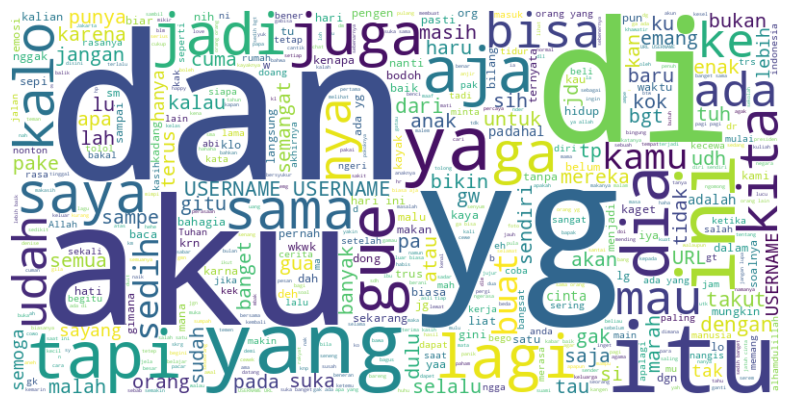

In [19]:
df_all['tweet'] = df_all['tweet'].fillna('')
text = ' '.join(df_all['tweet'].astype(str).tolist())

stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp'])

wordcloud = WordCloud(
    stopwords=stopwords,
    background_color='white',
    max_words=500,
    width=800,
    height=400
).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

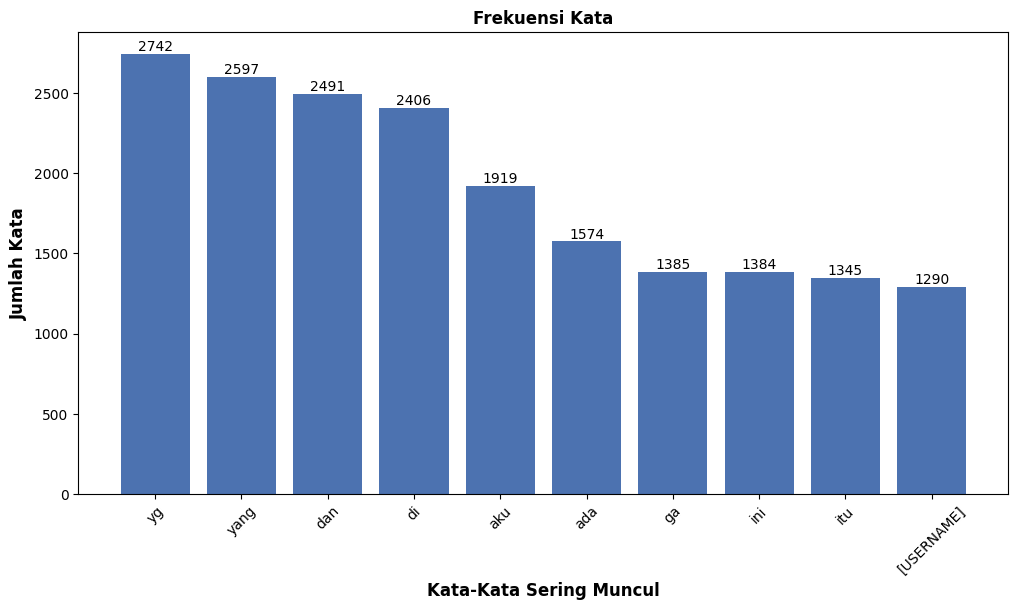

In [20]:
text = ' '.join(df_all['tweet'])

tokens = text.split()
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)
words, counts = zip(*top_words)

plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='#4C72B0')
plt.xlabel('Kata-Kata Sering Muncul', fontsize=12, fontweight='bold')
plt.ylabel('Jumlah Kata', fontsize=12, fontweight='bold')
plt.title('Frekuensi Kata', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)

for i, count in enumerate(counts):
    plt.text(i, count + 1, str(count), ha='center', va='bottom')
plt.show()

**Insight:**

Berdasarkan visualisasi wordcloud dan frekuensi kata:
- Berdasarkan visualisasi wordcloud, terlihat bahwa kata-kata seperti ya, yang, dan, di, aku, dan ada muncul dengan ukuran paling besar, yang menunjukkan bahwa kata-kata tersebut memiliki frekuensi kemunculan tertinggi dalam dataset tweet. Selain itu, masih muncul kata informal seperti gk, aja, dan kalo, serta token seperti USERNAME yang menandakan bahwa data masih berada dalam kondisi mentah (raw text) dan belum melalui proses preprocessing secara menyeluruh.
- Berdasarkan grafik frekuensi kata, kata ya menjadi kata yang paling sering muncul, diikuti oleh yang, dan, di, aku, dan ada. Dominasi kata-kata umum atau stopwords menunjukkan bahwa distribusi kata masih didominasi oleh struktur bahasa sehari-hari dibandingkan kata yang memiliki makna emosional atau topikal. Selain itu, keberadaan token seperti USERNAME menunjukkan masih adanya noise data seperti mention atau hasil scraping yang belum dibersihkan.

Secara keseluruhan, hasil eksplorasi teks menunjukkan bahwa dataset masih mengandung banyak stopwords, kata informal, dan noise data sehingga belum sepenuhnya siap digunakan untuk proses modeling NLP. Oleh karena itu, diperlukan tahapan preprocessing seperti cleaning text, stopword removal, case folding, serta normalisasi kata agar pola kata yang lebih relevan dan bermakna dapat digunakan dalam proses analisis emosi atau klasifikasi teks.

## Pre-Processing Data

**Lower case**

In [21]:
df_all['tweet_asli'] = df_all['tweet']

df_all['tweet'] = df_all['tweet'].str.lower()
df_all['label'] = df_all['label'].str.lower()

df_all.head()

,tweet,label,tweet_asli
0,pagi2 udah di buat emosi :),anger,pagi2 udah di buat emosi :)
1,"kok stabilitas negara, memange 10 thn negara t...",anger,"kok stabilitas negara, memange 10 thn negara t..."
2,dah lah emosi mulu liat emyu,anger,dah lah emosi mulu liat emyu
3,"aib? bodoh benar! sebelum kata aib itu muncul,...",anger,"aib? bodoh benar! sebelum kata aib itu muncul,..."
4,dih lu yg nyebelin bego,anger,dih lu yg nyebelin bego


**Insight:**

Proses tersebut dilakukan untuk menyimpan teks asli tweet pada kolom `tweet_asli` sebelum dilakukan *case folding*, yaitu mengubah seluruh huruf pada kolom `tweet` dan `label` menjadi huruf kecil. Tujuannya agar format teks menjadi seragam dan memudahkan proses analisis serta preprocessing NLP selanjutnya.

**Label Normalization**

In [22]:
df_all['label'] = df_all['label'].replace('joy', 'happy')
df_all['label'] = df_all['label'].replace('sadness', 'sad')
df_all = df_all.drop(df_all[df_all['label'] == 'love'].index)

print(df_all['label'].unique())
df_all.head()

['anger' 'fear' 'sad' 'happy' 'neutral']


,tweet,label,tweet_asli
0,pagi2 udah di buat emosi :),anger,pagi2 udah di buat emosi :)
1,"kok stabilitas negara, memange 10 thn negara t...",anger,"kok stabilitas negara, memange 10 thn negara t..."
2,dah lah emosi mulu liat emyu,anger,dah lah emosi mulu liat emyu
3,"aib? bodoh benar! sebelum kata aib itu muncul,...",anger,"aib? bodoh benar! sebelum kata aib itu muncul,..."
4,dih lu yg nyebelin bego,anger,dih lu yg nyebelin bego


**Insight:**

Pada tahap ini dilakukan pembersihan dan penyesuaian label emosi agar kategori menjadi lebih konsisten. Label joy diubah menjadi happy, sedangkan sadness diubah menjadi sad untuk menyeragamkan penamaan kelas. Selain itu, data dengan label love dihapus sehingga dataset hanya memiliki lima kategori emosi, yaitu anger, fear, sad, happy, dan neutral. Proses ini bertujuan agar label lebih terstruktur dan memudahkan proses analisis serta pemodelan klasifikasi emosi selanjutnya.

**Remove mention**

In [23]:
df_all['tweet'] = df_all['tweet'].str.replace(r'@\w+', '', regex=True)
df_all.head()

,tweet,label,tweet_asli
0,pagi2 udah di buat emosi :),anger,pagi2 udah di buat emosi :)
1,"kok stabilitas negara, memange 10 thn negara t...",anger,"kok stabilitas negara, memange 10 thn negara t..."
2,dah lah emosi mulu liat emyu,anger,dah lah emosi mulu liat emyu
3,"aib? bodoh benar! sebelum kata aib itu muncul,...",anger,"aib? bodoh benar! sebelum kata aib itu muncul,..."
4,dih lu yg nyebelin bego,anger,dih lu yg nyebelin bego


**Insight:**

Pada tahap ini dilakukan penghapusan mention atau username pada tweet menggunakan regex `@\w+`. Proses ini bertujuan untuk mengurangi noise pada data teks karena mention tidak memberikan informasi penting terhadap analisis emosi. Dengan menghapus mention, isi tweet menjadi lebih fokus pada konteks dan ekspresi emosi pengguna sehingga dapat meningkatkan kualitas preprocessing dan performa model NLP.

**Remove url**

In [24]:
def remove_url(text):
    return re.sub(r'http\S+|www\.\S+', '', text)

df_all['tweet'] = df_all['tweet'].apply(remove_url)
df_all.head()

,tweet,label,tweet_asli
0,pagi2 udah di buat emosi :),anger,pagi2 udah di buat emosi :)
1,"kok stabilitas negara, memange 10 thn negara t...",anger,"kok stabilitas negara, memange 10 thn negara t..."
2,dah lah emosi mulu liat emyu,anger,dah lah emosi mulu liat emyu
3,"aib? bodoh benar! sebelum kata aib itu muncul,...",anger,"aib? bodoh benar! sebelum kata aib itu muncul,..."
4,dih lu yg nyebelin bego,anger,dih lu yg nyebelin bego


**Insight:**

Pada tahap ini dilakukan penghapusan URL pada tweet menggunakan regular expression. Proses ini bertujuan untuk membersihkan data dari tautan seperti `http` atau `www` yang tidak memiliki kontribusi terhadap analisis emosi. Dengan menghapus URL, teks menjadi lebih bersih dan model NLP dapat lebih fokus pada kata-kata yang mengandung makna atau ekspresi emosional pengguna.


**Remove hashtag**

In [25]:
def remove_hashtags(text):
    return re.sub(r'#\w+', '', text)

df_all['tweet'] = df_all['tweet'].apply(remove_hashtags)
df_all.head()

,tweet,label,tweet_asli
0,pagi2 udah di buat emosi :),anger,pagi2 udah di buat emosi :)
1,"kok stabilitas negara, memange 10 thn negara t...",anger,"kok stabilitas negara, memange 10 thn negara t..."
2,dah lah emosi mulu liat emyu,anger,dah lah emosi mulu liat emyu
3,"aib? bodoh benar! sebelum kata aib itu muncul,...",anger,"aib? bodoh benar! sebelum kata aib itu muncul,..."
4,dih lu yg nyebelin bego,anger,dih lu yg nyebelin bego


**Insight:**

Pada tahap ini dilakukan penghapusan hashtag pada tweet menggunakan regular expression. Proses ini bertujuan untuk mengurangi noise pada data teks karena hashtag umumnya tidak memberikan informasi penting terhadap analisis emosi. Dengan menghapus hashtag, teks menjadi lebih bersih sehingga proses preprocessing dan analisis NLP dapat lebih fokus pada isi utama tweet.


**Word repetition normalization**

In [26]:
def handle_repetition(text):
    return re.sub(r'([a-zA-Z]+)2', r'\1 \1', text)

df_all['tweet'] = df_all['tweet'].apply(handle_repetition)
df_all.head()

,tweet,label,tweet_asli
0,pagi pagi udah di buat emosi :),anger,pagi2 udah di buat emosi :)
1,"kok stabilitas negara, memange 10 thn negara t...",anger,"kok stabilitas negara, memange 10 thn negara t..."
2,dah lah emosi mulu liat emyu,anger,dah lah emosi mulu liat emyu
3,"aib? bodoh benar! sebelum kata aib itu muncul,...",anger,"aib? bodoh benar! sebelum kata aib itu muncul,..."
4,dih lu yg nyebelin bego,anger,dih lu yg nyebelin bego


**Insight:**

Pada tahap ini dilakukan normalisasi pengulangan kata pada tweet, seperti mengubah kata singkatan atau penulisan berulang menjadi bentuk yang lebih jelas dan mudah dipahami. Hasil preprocessing menunjukkan beberapa kata informal berhasil dinormalisasi, seperti `pagi2` menjadi `pagi pagi`. Proses ini bertujuan untuk membuat teks lebih konsisten sehingga dapat membantu model NLP memahami konteks dan makna kata dengan lebih baik.


**Remove punctuation**

In [27]:
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

df_all['tweet'] = df_all['tweet'].apply(remove_punctuation)
df_all.head()

,tweet,label,tweet_asli
0,pagi pagi udah di buat emosi,anger,pagi2 udah di buat emosi :)
1,kok stabilitas negara memange 10 thn negara td...,anger,"kok stabilitas negara, memange 10 thn negara t..."
2,dah lah emosi mulu liat emyu,anger,dah lah emosi mulu liat emyu
3,aib bodoh benar sebelum kata aib itu muncul te...,anger,"aib? bodoh benar! sebelum kata aib itu muncul,..."
4,dih lu yg nyebelin bego,anger,dih lu yg nyebelin bego


**Insight:**

Pada tahap ini dilakukan penghapusan tanda baca (*punctuation removal*) pada tweet menggunakan fungsi `string.punctuation`. Proses ini bertujuan untuk membersihkan karakter seperti koma, tanda seru, tanda tanya, dan simbol lainnya yang tidak memiliki pengaruh signifikan terhadap analisis teks. Dengan menghapus tanda baca, teks menjadi lebih bersih dan memudahkan proses tokenisasi serta analisis NLP selanjutnya.

**Remove symbols**

In [28]:
def remove_symbols(text):
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text

df_all['tweet'] = df_all['tweet'].apply(remove_symbols)
df_all.head()

,tweet,label,tweet_asli
0,pagi pagi udah di buat emosi,anger,pagi2 udah di buat emosi :)
1,kok stabilitas negara memange 10 thn negara td...,anger,"kok stabilitas negara, memange 10 thn negara t..."
2,dah lah emosi mulu liat emyu,anger,dah lah emosi mulu liat emyu
3,aib bodoh benar sebelum kata aib itu muncul te...,anger,"aib? bodoh benar! sebelum kata aib itu muncul,..."
4,dih lu yg nyebelin bego,anger,dih lu yg nyebelin bego


**Insight:**

Pada tahap ini dilakukan penghapusan simbol dan karakter khusus pada tweet agar teks menjadi lebih bersih dan rapi. Proses ini membantu mengurangi noise pada data sehingga analisis NLP dapat lebih fokus pada kata-kata yang memiliki makna dalam tweet.

**Characters Normalize**

In [29]:
def normalize_repeated_chars(text):
    return re.sub(r'(.)\1{2,}', r'\1', text)

df_all['tweet'] = df_all['tweet'].apply(normalize_repeated_chars)
df_all.head()

,tweet,label,tweet_asli
0,pagi pagi udah di buat emosi,anger,pagi2 udah di buat emosi :)
1,kok stabilitas negara memange 10 thn negara td...,anger,"kok stabilitas negara, memange 10 thn negara t..."
2,dah lah emosi mulu liat emyu,anger,dah lah emosi mulu liat emyu
3,aib bodoh benar sebelum kata aib itu muncul te...,anger,"aib? bodoh benar! sebelum kata aib itu muncul,..."
4,dih lu yg nyebelin bego,anger,dih lu yg nyebelin bego


**Insight:**

Pada tahap ini dilakukan normalisasi huruf yang ditulis berulang pada tweet, seperti kata dengan penulisan berlebihan untuk menunjukkan ekspresi tertentu. Proses ini bertujuan agar kata menjadi lebih normal dan konsisten sehingga lebih mudah dipahami oleh model NLP saat proses analisis teks dilakukan.


**Normalization of non-standard words**

In [30]:
nltk.download('punkt')
dictionary_df = pd.read_csv("kata_baku.csv")

spelling_correction = dict(zip(dictionary_df['tidak_baku'], dictionary_df['kata_baku']))
def correct_spelling(text, corrections):
    words = text.split()
    corrected_words = [corrections.get(word, word) for word in words]
    return ' '.join(corrected_words)

df_all['tweet'] = df_all['tweet'].apply(lambda x: correct_spelling(x, spelling_correction))
df_all.head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


,tweet,label,tweet_asli
0,pagi pagi sudah di buat emosi,anger,pagi2 udah di buat emosi :)
1,kok stabilitas negara memange 10 tahun negara ...,anger,"kok stabilitas negara, memange 10 thn negara t..."
2,sudah lah emosi mulu lihat emyu,anger,dah lah emosi mulu liat emyu
3,aib bodoh benar sebelum kata aib itu muncul te...,anger,"aib? bodoh benar! sebelum kata aib itu muncul,..."
4,dih kamu yang menyebalkan bego,anger,dih lu yg nyebelin bego


**Insight:**

Pada tahap ini dilakukan normalisasi kata tidak baku menjadi kata baku menggunakan kamus kata (`kata_baku.csv`). Proses ini bertujuan untuk mengubah kata informal atau singkatan menjadi bentuk yang lebih standar, seperti `udah` menjadi `sudah`, `thn` menjadi `tahun`, `liat` menjadi `lihat`, dan `yg` menjadi `yang`. Dengan normalisasi ini, teks menjadi lebih konsisten dan memudahkan model NLP dalam memahami makna kata pada tweet.


**Slang normalization**

In [31]:
slang_words_file = 'combined_slang_words.txt'

try:
    with open(slang_words_file, 'r', encoding='utf-8') as file:
        slang_words_dict = json.load(file)

except FileNotFoundError:
    slang_words_dict = {}
    print(f"Warning: File '{slang_words_file}' tidak ditemukan (JSON slang kosong).")

try:
    slang_csv = pd.read_csv('slang_indo_fix.csv')
    slang_csv_dict = dict(zip(slang_csv.iloc[:, 0], slang_csv.iloc[:, 1]))

except FileNotFoundError:
    slang_csv_dict = {}
    print("Warning: slang_indo_fix.csv tidak ditemukan.")

slang_words_dict.update(slang_csv_dict)

def normalize_slang(text, slang_dict):
    if isinstance(text, str):
        words = text.split()
        normalized_words = [slang_dict.get(word, word) for word in words]
        return ' '.join(normalized_words)
    return text

df_all['tweet'] = df_all['tweet'].apply(
    lambda x: normalize_slang(x, slang_words_dict)
)

df_all.head()

,tweet,label,tweet_asli
0,pagi pagi sudah di buat emosi,anger,pagi2 udah di buat emosi :)
1,kok stabilitas negara memange 10 tahun negara ...,anger,"kok stabilitas negara, memange 10 thn negara t..."
2,sudah lah emosi terus lihat manchester united,anger,dah lah emosi mulu liat emyu
3,aib bodoh benar sebelum kata aib itu muncul te...,anger,"aib? bodoh benar! sebelum kata aib itu muncul,..."
4,dih kamu yang menyebalkan bodoh,anger,dih lu yg nyebelin bego


**Insight:**

Pada tahap ini dilakukan normalisasi kata slang atau bahasa gaul menjadi kata yang lebih baku menggunakan kamus slang dari file `.txt` dan `.csv`. Proses ini membantu mengubah kata informal menjadi lebih mudah dipahami, seperti `mulu` menjadi `terus`, `emyu` menjadi `manchester united`, dan `nyebelin` menjadi `menyebalkan`. Dengan normalisasi slang, teks menjadi lebih konsisten sehingga dapat meningkatkan kualitas analisis dan performa model NLP.

**Remove duplicates**

In [32]:
df_all.drop_duplicates(subset = 'tweet', keep = 'first', inplace = True)
df_all.head()

,tweet,label,tweet_asli
0,pagi pagi sudah di buat emosi,anger,pagi2 udah di buat emosi :)
1,kok stabilitas negara memange 10 tahun negara ...,anger,"kok stabilitas negara, memange 10 thn negara t..."
2,sudah lah emosi terus lihat manchester united,anger,dah lah emosi mulu liat emyu
3,aib bodoh benar sebelum kata aib itu muncul te...,anger,"aib? bodoh benar! sebelum kata aib itu muncul,..."
4,dih kamu yang menyebalkan bodoh,anger,dih lu yg nyebelin bego


**Insight:**

Pada tahap ini dilakukan penghapusan data duplikat pada kolom tweet dengan hanya mempertahankan data pertama (keep='first'). Proses ini bertujuan untuk menghindari adanya tweet yang sama muncul lebih dari satu kali sehingga dataset menjadi lebih bersih dan tidak memengaruhi hasil analisis maupun performa model NLP.

**Remove invalid words**

In [33]:
def remove_no_vowel_words(text):
    words = text.split()
    clean_words = [word for word in words if re.search(r'[aiueo]', word)]
    return ' '.join(clean_words)

df_all['tweet'] = df_all['tweet'].apply(remove_no_vowel_words)
df_all.head()

,tweet,label,tweet_asli
0,pagi pagi sudah di buat emosi,anger,pagi2 udah di buat emosi :)
1,kok stabilitas negara memange tahun negara tid...,anger,"kok stabilitas negara, memange 10 thn negara t..."
2,sudah lah emosi terus lihat manchester united,anger,dah lah emosi mulu liat emyu
3,aib bodoh benar sebelum kata aib itu muncul te...,anger,"aib? bodoh benar! sebelum kata aib itu muncul,..."
4,dih kamu yang menyebalkan bodoh,anger,dih lu yg nyebelin bego


**Insight:**

Pada tahap ini dilakukan penghapusan kata yang tidak memiliki huruf vokal pada tweet. Proses ini bertujuan untuk mengurangi noise atau kata tidak jelas yang kemungkinan berasal dari typo, singkatan tidak valid, atau karakter acak. Dengan menghapus kata tersebut, teks menjadi lebih bersih dan lebih mudah diproses pada tahap analisis NLP selanjutnya.

**Export to csv**

In [34]:
output_file_full = 'output_prepros_data_emoticon.csv'

output_file = 'output_prepros.csv'

try:
    df_all.to_csv(output_file_full, index=False)

    df_clean = df_all.drop(columns=['tweet_asli'])
    df_clean.to_csv(output_file, index=False)

    print(f"File lengkap berhasil disimpan {output_file_full}")
    print(f"File tanpa tweet_asli berhasil disimpan {output_file}")

except Exception as e:
    print(f"Terjadi kesalahan saat menyimpan file: {e}")

File lengkap berhasil disimpan output_prepros_data_emoticon.csv
File tanpa tweet_asli berhasil disimpan output_prepros.csv


## EDA Setelah Pre-Processing

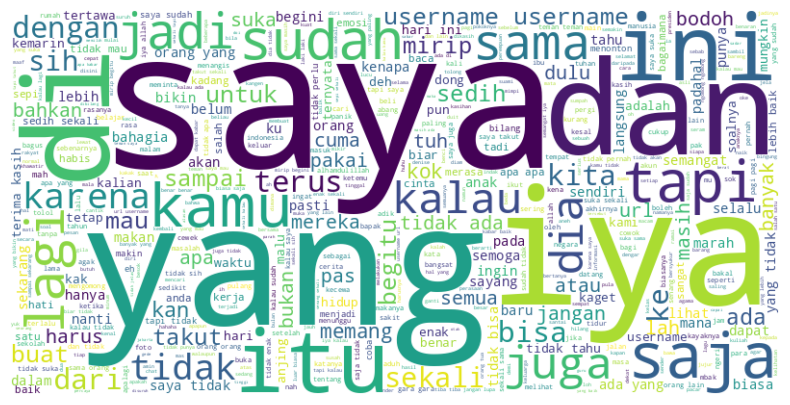

In [35]:
df_all['tweet'] = df_all['tweet'].fillna('')
text = ' '.join(df_all['tweet'].astype(str).tolist())

stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp'])

wordcloud = WordCloud(stopwords=stopwords, background_color='white', max_words=500, width=800, height=400).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

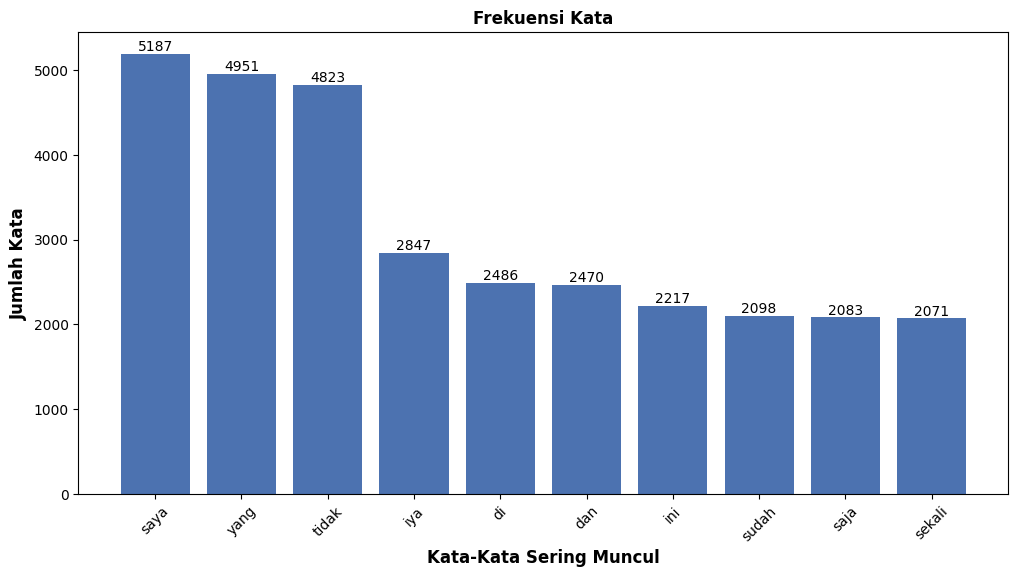

In [36]:
text = ' '.join(df_all['tweet'])

tokens = text.split()
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)
words, counts = zip(*top_words)

plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='#4C72B0')
plt.xlabel('Kata-Kata Sering Muncul', fontsize=12, fontweight='bold')
plt.ylabel('Jumlah Kata', fontsize=12, fontweight='bold')
plt.title('Frekuensi Kata', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)

for i, count in enumerate(counts):
    plt.text(i, count + 1, str(count), ha='center', va='bottom')
plt.show()

## Visualisasi & Explanatory Analysis

In [37]:
data = pd.read_csv('output_prepros.csv')
data.head()

,tweet,label
0,pagi pagi sudah di buat emosi,anger
1,kok stabilitas negara memange tahun negara tid...,anger
2,sudah lah emosi terus lihat manchester united,anger
3,aib bodoh benar sebelum kata aib itu muncul te...,anger
4,dih kamu yang menyebalkan bodoh,anger


### Pertanyaan 1
Label emosi apa yang paling dominan pada tweet pengguna media sosial berdasarkan kategori happy, fear, sad, anger, dan neutral dalam dataset, sehingga dapat menentukan fokus utama evaluasi emosi pengguna?

In [38]:
jumlah_emosi = data['label'].value_counts()

hasil_emosi = pd.DataFrame({
    'Jumlah Tweet': jumlah_emosi})

print(hasil_emosi)
emosi_dominan = jumlah_emosi.idxmax()
print(f"\nEmosi paling dominan adalah: {emosi_dominan}")

         Jumlah Tweet
label                
happy            2249
anger            2220
neutral          1976
sad              1975
fear             1542

Emosi paling dominan adalah: happy


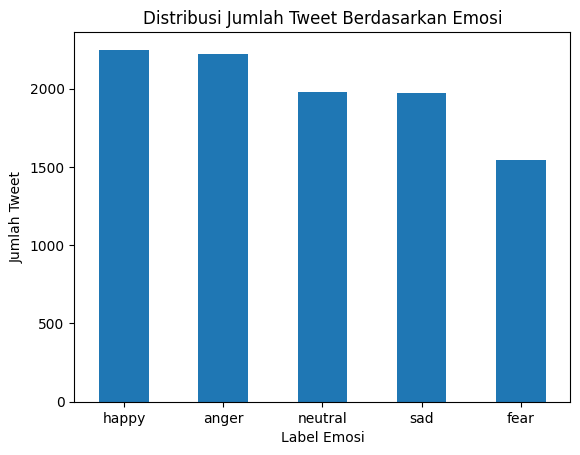

In [39]:
hasil_emosi['Jumlah Tweet'].plot(kind='bar')

plt.title('Distribusi Jumlah Tweet Berdasarkan Emosi')
plt.xlabel('Label Emosi')
plt.ylabel('Jumlah Tweet')
plt.xticks(rotation=0)

plt.show()

**Insight:**

Berdasarkan distribusi jumlah tweet pada masing-masing label emosi:

- Emosi **happy** menjadi kategori yang paling dominan dengan **2.249** tweet, menunjukkan bahwa sebagian besar pengguna media sosial dalam dataset cenderung mengekspresikan emosi positif.
- Emosi **anger** berada pada jumlah yang hampir setara dengan happy yaitu **2.220** tweet, mengindikasikan bahwa ekspresi kemarahan juga cukup sering muncul pada tweet pengguna.
- Emosi **neutral (1.976 tweet)** dan **sad (1.975 tweet)** memiliki jumlah yang hampir sama, menunjukkan bahwa ekspresi netral dan kesedihan muncul dengan intensitas yang relatif seimbang.
- Emosi **fear** menjadi kategori dengan jumlah paling sedikit, yaitu **1.542** tweet, sehingga menunjukkan bahwa ekspresi rasa takut lebih jarang ditemukan dibandingkan emosi lainnya.
- Visualisasi diagram batang memperlihatkan bahwa **distribusi data relatif cukup merata**, meskipun happy dan anger sedikit lebih dominan dibandingkan kategori emosi lainnya.

Secara keseluruhan, hasil ini menunjukkan bahwa fokus evaluasi emosi pengguna media sosial dapat lebih diarahkan pada emosi happy dan anger karena keduanya memiliki frekuensi kemunculan tertinggi dalam dataset.

### Pertanyaan 2
Bagaimana distribusi persentase tweet pada masing-masing label emosi happy, fear, sad, anger, dan neutral untuk mengetahui kecenderungan emosi pengguna media sosial dalam dataset

In [40]:
persentase_emosi = (
    data['label']
    .value_counts(normalize=True) * 100).round(2)

hasil_persentase = pd.DataFrame({
    'Persentase (%)': persentase_emosi
})

print(hasil_persentase)

         Persentase (%)
label                  
happy             22.58
anger             22.28
neutral           19.84
sad               19.83
fear              15.48


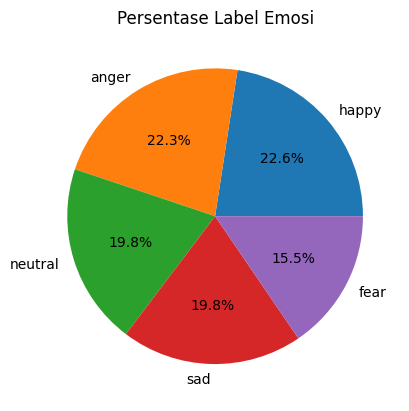

In [41]:
persentase_emosi.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Persentase Label Emosi')
plt.ylabel('')

plt.show()

**Insight:**

Berdasarkan hasil persentase label emosi pada dataset:
- Emosi **happy** memiliki persentase tertinggi sebesar **22,58%**, diikuti **anger** sebesar **22,28%**, menunjukkan bahwa emosi positif dan kemarahan menjadi emosi yang paling sering muncul pada tweet pengguna.
- Emosi **neutral (19,84%)** dan **sad (19,83%)** memiliki persentase yang hampir sama, sehingga menunjukkan distribusi yang relatif seimbang di antara keduanya.
- Emosi **fear** memiliki persentase paling rendah sebesar **15,48%**, yang mengindikasikan bahwa ekspresi rasa takut lebih jarang ditemukan dalam dataset.

Berdasarkan visualisasi diagram pie, **distribusi emosi pada dataset cukup seimbang** karena tidak ada satu kategori yang mendominasi secara ekstrem. Namun, emosi happy dan anger sedikit lebih dominan dibanding kategori lainnya, sehingga keduanya dapat menjadi fokus utama dalam analisis perilaku dan pola emosi pengguna media sosial.


### Pertanyaan 3
Apakah terdapat ketidakseimbangan jumlah data pada label emosi happy, fear, sad, anger, dan neutral yang dapat memengaruhi proses pelatihan model klasifikasi emosi?

In [42]:
jumlah_label = data['label'].value_counts()

hasil_keseimbangan = pd.DataFrame({
    'Jumlah Data': jumlah_label
})

print(hasil_keseimbangan)

jumlah_terbesar = jumlah_label.max()
jumlah_terkecil = jumlah_label.min()

rasio = round(jumlah_terbesar / jumlah_terkecil, 2)

print(f"\nJumlah terbesar : {jumlah_terbesar}")
print(f"Jumlah terkecil : {jumlah_terkecil}")
print(f"Rasio data      : {rasio}")

if rasio > 1.5:
    print("\nKesimpulan: Dataset tidak seimbang")
else:
    print("\nKesimpulan: Dataset cukup seimbang")

         Jumlah Data
label               
happy           2249
anger           2220
neutral         1976
sad             1975
fear            1542

Jumlah terbesar : 2249
Jumlah terkecil : 1542
Rasio data      : 1.46

Kesimpulan: Dataset cukup seimbang


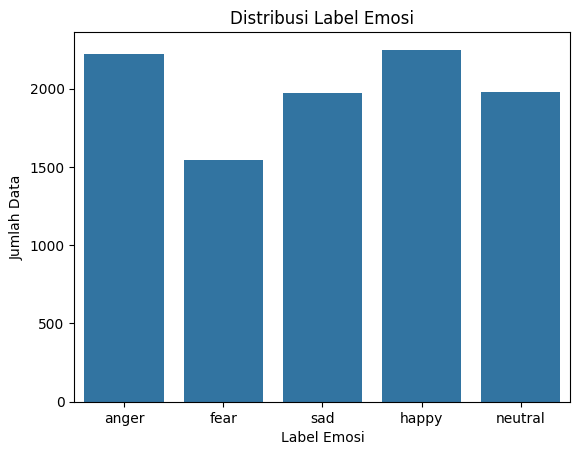

In [43]:
sns.countplot(x='label', data=data)

plt.title('Distribusi Label Emosi')
plt.xlabel('Label Emosi')
plt.ylabel('Jumlah Data')

plt.show()

**Insight:**

Berdasarkan distribusi jumlah tweet pada masing-masing label emosi:
- Emosi **happy** menjadi kategori dengan jumlah tertinggi yaitu **2.249** tweet, diikuti oleh **anger** dengan **2.220** tweet. Hal ini menunjukkan bahwa emosi positif dan kemarahan merupakan emosi yang paling dominan muncul dalam dataset.
- Emosi **neutral (1.976 tweet)** dan **sad (1.975 tweet)** memiliki jumlah yang hampir sama, sehingga menunjukkan distribusi yang relatif seimbang antara ekspresi netral dan kesedihan.
- Emosi **fear** menjadi kategori dengan jumlah paling sedikit yaitu **1.542** tweet, sehingga menunjukkan bahwa ekspresi rasa takut relatif lebih jarang muncul dibandingkan emosi lainnya.
- Berdasarkan **perhitungan rasio terbesar-terkecil** sebesar **1.46**, dataset dapat dikategorikan cukup seimbang (mild imbalance), sehingga potensi bias model terhadap kelas mayoritas masih tergolong rendah namun tetap perlu diwaspadai.
- Visualisasi countplot menunjukkan bahwa sebaran data antar kelas tidak terlalu timpang, meskipun terdapat perbedaan yang cukup terlihat antara kelas fear dan kelas lainnya.

Secara keseluruhan, kondisi dataset yang cukup seimbang ini dapat membantu proses pelatihan model klasifikasi emosi agar tidak terlalu bias terhadap label tertentu dan mampu mengenali berbagai kategori emosi dengan lebih baik.

## Feature Engineering

In [44]:
# FEATURE ENGINEERING 1
# LABEL ENCODING

label_mapping = {
    'anger': 0,
    'fear': 1,
    'sad': 2,
    'neutral': 3,
    'happy': 4
}

data['label_id'] = data['label'].map(label_mapping)
data.head()

,tweet,label,label_id
0,pagi pagi sudah di buat emosi,anger,0
1,kok stabilitas negara memange tahun negara tid...,anger,0
2,sudah lah emosi terus lihat manchester united,anger,0
3,aib bodoh benar sebelum kata aib itu muncul te...,anger,0
4,dih kamu yang menyebalkan bodoh,anger,0


In [45]:
# FEATURE ENGINEERING 2
# JUMLAH KATA

data['jumlah_kata'] = data['tweet'].apply(
    lambda x: len(str(x).split()))

data.head()

,tweet,label,label_id,jumlah_kata
0,pagi pagi sudah di buat emosi,anger,0,6
1,kok stabilitas negara memange tahun negara tid...,anger,0,24
2,sudah lah emosi terus lihat manchester united,anger,0,7
3,aib bodoh benar sebelum kata aib itu muncul te...,anger,0,40
4,dih kamu yang menyebalkan bodoh,anger,0,5


In [46]:
# FEATURE ENGINEERING 3
# PANJANG KARAKTER

data['panjang_karakter'] = data['tweet'].apply(
    lambda x: len(str(x)))

data.head()

,tweet,label,label_id,jumlah_kata,panjang_karakter
0,pagi pagi sudah di buat emosi,anger,0,6,29
1,kok stabilitas negara memange tahun negara tid...,anger,0,24,184
2,sudah lah emosi terus lihat manchester united,anger,0,7,45
3,aib bodoh benar sebelum kata aib itu muncul te...,anger,0,40,273
4,dih kamu yang menyebalkan bodoh,anger,0,5,31


In [47]:
output_data_final = 'output_data_final.csv'

try:
    # Simpan hasil akhir
    data.to_csv(output_data_final, index=False)

    print(f"File berhasil disimpan: {output_data_final}")

except Exception as e:
    print(f"Terjadi kesalahan saat menyimpan file: {e}")

File berhasil disimpan: output_data_final.csv


## A/B Testing

In [48]:
from scipy.stats import ttest_ind

# MEMBUAT KELOMPOK A DAN B
group_A = data[data['label'] == 'happy']['jumlah_kata']
group_B = data[data['label'] == 'sad']['jumlah_kata']

# MENAMPILKAN RATA-RATA
print("Rata-rata jumlah kata Happy :", round(group_A.mean(), 2))
print("Rata-rata jumlah kata Sad   :", round(group_B.mean(), 2))

# MELAKUKAN INDEPENDENT T-TEST
t_stat, p_value = ttest_ind(group_A, group_B)

# MENAMPILKAN HASIL
print("\n=== HASIL T-TEST ===")
print(f"T-Statistic : {t_stat:.4e}")
print(f"P-Value : {p_value:.4e}")

# INTERPRETASI HASIL
alpha = 0.05

print("\n=== INTERPRETASI ===")

if p_value < alpha:
    print("H0 ditolak. Terdapat perbedaan signifikan antara emosi happy dan sad, sehingga menunjukkan bahwa jumlah kata pada kedua emosi memiliki perbedaan yang signifikan.")
else:
    print("H0 diterima. Tidak terdapat perbedaan signifikan antara emosi happy dan sad.")

Rata-rata jumlah kata Happy : 19.14
Rata-rata jumlah kata Sad   : 22.38

=== HASIL T-TEST ===
T-Statistic : -7.7997e+00
P-Value : 7.7656e-15

=== INTERPRETASI ===
H0 ditolak. Terdapat perbedaan signifikan antara emosi happy dan sad, sehingga menunjukkan bahwa jumlah kata pada kedua emosi memiliki perbedaan yang signifikan.


**Insight:**

Berdasarkan hasil independent t-test antara kelompok emosi happy (A) dan sad (B), diperoleh hasil sebagai berikut:
- Rata-rata jumlah kata pada emosi **happy** adalah **19,14**, sedangkan pada emosi **sad** lebih tinggi yaitu **22,38**.
- Nilai **t-statistic = -7,7997** menunjukkan adanya perbedaan rata-rata dengan arah bahwa kelompok sad memiliki jumlah kata yang lebih besar.
- Nilai **p-value = 7,77 × 10⁻¹⁵**, jauh lebih kecil dari α = 0,05, menunjukkan bahwa terdapat perbedaan yang signifikan antara jumlah kata pada emosi happy dan sad, sehingga **hipotesis nol (H0) ditolak**.

Interpretasi:
Terdapat perbedaan yang sangat signifikan secara statistik antara jumlah kata pada tweet beremosi happy dan sad. Hasil ini menunjukkan bahwa pengguna cenderung menulis lebih panjang saat mengekspresikan emosi sad, sedangkan emosi happy umumnya disampaikan dengan lebih singkat dan langsung.